In [1]:
import pandas as pd
from pandas.tseries.offsets import DateOffset
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata
import datetime as dt
from pathlib import Path
import os
from tqdm import tqdm
from fnmatch import fnmatch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.spatial.distance import cdist
import datacube
from datacube.drivers.netcdf import write_dataset_to_netcdf
import plotly.express as px
from scipy import stats
from scipy.stats import pearsonr
import seaborn as sns

In [2]:
#Function to select certain variables from files and concatenate
def process_daily_files(result_dir, files_to_open, variables_to_select, progress_bar=None):
    # Open the daily files as an xarray dataset
    ds = xr.open_mfdataset(str(result_dir / files_to_open), combine='nested')

    # Select specific variables
    ds = ds[variables_to_select]

    # Update progress bar
    if progress_bar:
        progress_bar.update(1)
    return ds

# Function to calculate Haversine distance from observed monitoring sites and irregularly gridded cells
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0  # approximate radius of Earth in km
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad

    a = np.sin(dlat / 2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c
    return distance

def find_index(array, x):
    if array.ndim == 1:
        idx = np.argmin(np.abs(array - x))
    elif array.ndim == 2:
        idx = np.unravel_index(np.argmin(np.abs(array - x)), array.shape)
    else:
        raise ValueError("Unsupported array dimensions for find_index function.")
    return idx

def nrmse(observed, modelled):
    mse = np.mean((observed - modelled) ** 2)
    rmse_value = np.sqrt(mse)
    normalized_rmse = rmse_value / np.mean(observed)  # Normalize by mean
    return normalized_rmse

def calculate_cohens_d(modelled, observed):
    # Calculate the mean difference
    mean_diff = np.mean(modelled) - np.mean(observed)
    
    # Calculate the pooled standard deviation
    pooled_std = np.sqrt(((np.std(modelled, ddof=1) ** 2 + np.std(observed, ddof=1) ** 2) / 2))
    
    # Calculate Cohen's d
    cohens_d = abs(mean_diff / pooled_std)
    
    return cohens_d

def interpret_cohens_d(d):
    if d < 0.2:
        return "Small effect"
    elif 0.2 <= d < 0.8:
        return "Medium effect"
    else:
        return "Large effect"

In [3]:
# Define bounding box for CONUS (approximate)
lat_min, lat_max = 24.396308, 49.384358  # Southernmost and northernmost points
lon_min, lon_max = -125.0, -66.93457    # Westernmost and easternmost points

# Number of random points to generate
num_points = 2000  # Adjust for desired density

# Generate random latitudes and longitudes within the bounding box
lats = np.random.uniform(lat_min, lat_max, num_points)
lons = np.random.uniform(lon_min, lon_max, num_points)

# Create a Pandas DataFrame
random_points = pd.DataFrame({'latitude': lats, 'longitude': lons})
random_points.reset_index(inplace = True)
random_points['lon'] = 360-(random_points['longitude']*-1)
#random_points
#plot the points
#fig = px.scatter_geo(random_points, lat='latitude',  lon='longitude',   scope='usa')  # Set scope to USA for zoomed-in ma template='plotly')
#fig.show()


In [4]:
#Read in MUSICA data
result_dir = Path('/glade/derecho/scratch/demurray/archive/MUSICA_FCnudged30x8_20172018_082024/atm/hist')

files_to_open = 'MUSICA_FCnudged30x8_20172018_082024.cam.h0.*.nc'

variables_to_select = ['lat', 'lon', 'area','pom_a1SFWET', 'pom_a4SFWET', 'pom_c1SFWET', 'pom_c4SFWET', 
                       'soa1_a1SFWET', 'soa1_c1SFWET', 'soa1_a2SFWET', 'soa1_c2SFWET', 
                       'soa2_a1SFWET', 'soa2_c1SFWET', 'soa2_a2SFWET', 'soa2_c2SFWET', 
                       'soa3_a1SFWET', 'soa3_c1SFWET', 'soa3_a2SFWET',  'soa3_c2SFWET', 
                       'soa4_a1SFWET', 'soa4_c1SFWET', 'soa4_a2SFWET',  'soa4_c2SFWET', 
                       'soa5_a1SFWET', 'soa5_c1SFWET', 'soa5_a2SFWET',  'soa5_c2SFWET', 
                       'bc_a1SFWET', 'bc_a4SFWET', 'bc_c1SFWET', 'bc_c4SFWET', 'so4_a1SFWET', 
                       'so4_a2SFWET', 'so4_a3SFWET', 'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET',
                       'WD_NH4', 'WD_HNO3', 'WD_NH3', 'PRECC', 'PRECL']

files_list = list(result_dir.glob(files_to_open))

# Initialize tqdm progress bar
progress = tqdm(total=len(files_list))

processed_data = []
for file in files_list:
    processed_data.append(process_daily_files(result_dir, file.relative_to(result_dir), variables_to_select, progress_bar=progress))

progress.close()

musica_daily = xr.concat(processed_data, dim='time').sortby('time')
musica_daily

100%|██████████| 729/729 [02:29<00:00,  4.88it/s]


<xarray.Dataset>
Dimensions:       (time: 729, ncol: 174098)
Coordinates:
  * time          (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
Dimensions without coordinates: ncol
Data variables: (12/42)
    lat           (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    lon           (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    area          (time, ncol) float64 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_a4SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    pom_c1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    ...            ...
    so4_c3SFWET   (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH4        (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_HNO3       (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    WD_NH3        (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECC         (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
    PRECL         (time, ncol) float32 dask.array<chunksize=(1, 174098), meta=np.ndarray>
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICA_FCnudged30x8_20172018_082024
    logname:           demurray
    host:              derecho3
    initial_file:      /glade/derecho/scratch/demurray/inic/f.e22.FCnudged.ne...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [5]:
#Subset lat and lon for only over north america
musica_dim = musica_daily[['lat', 'lon']]
clipped_lat = musica_daily['lat'].clip(min=24, max=50)
clipped_lon = musica_daily['lon'].clip(min=235, max=294)

# Step 2: Update the dataset with clipped variables
musica_clipped = musica_dim.assign(lat=clipped_lat, lon=clipped_lon)
#musica_clipped

#Step 3. convert to a dataframe
mus_dim_df = musica_clipped.to_dataframe().reset_index()
mus_dim_df = mus_dim_df[['ncol', 'lat','lon']].drop_duplicates()
mus_dim_df = mus_dim_df.set_index('ncol')
mus_dim_df

,lat,lon
ncol,,
0,24.000000,235.000000
1,24.000000,235.000000
2,24.000000,235.375435
3,24.000000,235.764926
4,24.000000,235.000000
...,...,...
174093,47.263011,294.000000
174094,47.377896,294.000000
174095,47.216640,294.000000


In [6]:
# Calculate distances between all points in mus_df and random_points
distances = np.zeros((len(mus_dim_df), len(random_points)))

# Use tqdm to add a progress bar
for i, row in tqdm(mus_dim_df.iterrows(), total=len(mus_dim_df), desc='Calculating distances'):
    for j, row_random in random_points.iterrows():
        distances[i, j] = haversine(row['lat'], row['lon'], row_random['latitude'], row_random['lon'])

Calculating distances: 100%|██████████| 174098/174098 [5:13:24<00:00,  9.26it/s]  


In [7]:
random_points['pointId'] = random_points['index']
random_points

,index,latitude,longitude,lon,pointId
0,0,48.350275,-122.737263,237.262737,0
1,1,40.658743,-88.918901,271.081099,1
2,2,47.612147,-78.204205,281.795795,2
3,3,43.489026,-96.486458,263.513542,3
4,4,28.502740,-113.939598,246.060402,4
...,...,...,...,...,...
1995,1995,32.681237,-83.606017,276.393983,1995
1996,1996,43.376086,-69.595338,290.404662,1996
1997,1997,28.099650,-105.109124,254.890876,1997
1998,1998,45.613014,-94.798280,265.201720,1998


In [8]:
# Find the index of the closest point in mus_df for each point in random points
random_points['pointId'] = random_points['index']
closest_indices = np.argmin(distances, axis=0)

# Keep only the latitude and longitude pairs in mus_df that correspond to the closest points in ntn_loc
mus_df_matched = mus_dim_df.iloc[closest_indices]

# Assign the corresponding 'pointId' from random_points to mus_df_matched
mus_df_matched['index'] = random_points['pointId'].values
mus_df_matched = mus_df_matched.rename(columns = {'lat': 'lat_mod', 'lon' : 'lon_mod'})
mus_df_matched.reset_index(inplace = True) #checks -- there should be the same length of cells in mus_df_matched as ntn_loc
mus_df_matched['pointId'] = mus_df_matched['index']

mus_random = pd.merge(mus_df_matched, random_points, on = 'pointId', how = 'left') #looks good!
mus_random = mus_random[['ncol', 'lat_mod', 'lon_mod', 'pointId', 'latitude', 'longitude', 'lon']]
mus_random

/glade/derecho/scratch/demurray/tmp/ipykernel_11457/139908582.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mus_df_matched['index'] = random_points['pointId'].values


,ncol,lat_mod,lon_mod,pointId,latitude,longitude,lon
0,166030,48.392624,237.329976,0,48.350275,-122.737263,237.262737
1,139268,40.717770,271.123937,1,40.658743,-88.918901,271.081099
2,161606,47.652491,281.878241,2,47.612147,-78.204205,281.795795
3,138669,43.481365,263.413661,3,43.489026,-96.486458,263.513542
4,93493,28.461364,246.016801,4,28.502740,-113.939598,246.060402
...,...,...,...,...,...,...,...
1995,123527,32.773341,276.333471,1995,32.681237,-83.606017,276.393983
1996,162426,43.351397,290.480395,1996,43.376086,-69.595338,290.404662
1997,98579,28.051243,254.817271,1997,28.099650,-105.109124,254.890876
1998,155065,45.600627,265.288783,1998,45.613014,-94.798280,265.201720


In [9]:
#from here, make a dictionary of point ids that corresponds with model lat and lon and then 
#subset the xarray by this dictionary before perfroming any dataframe manipulation
# Step 1: Subset the xarray.Dataset using ncol
subset_ds = musica_daily.sel(ncol=mus_df_matched['ncol'].values)

# Step 2: Assign pointId to the subset xarray.Dataset
# Convert DataFrame to xarray.Dataset for easier assignment
pointId_da = xr.DataArray(mus_df_matched['pointId'].values, dims=['ncol'], coords={'ncol': mus_df_matched['ncol'].values})
subset_ds_RR = subset_ds.assign(pointId=pointId_da)
subset_ds_RR

<xarray.Dataset>
Dimensions:       (time: 729, ncol: 2000)
Coordinates:
  * time          (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol          (ncol) int64 166030 139268 161606 ... 98579 155065 139454
Data variables: (12/43)
    lat           (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    lon           (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    area          (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_a1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_a4SFWET   (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pom_c1SFWET   (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    ...            ...
    WD_NH4        (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_HNO3       (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH3        (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECC         (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PRECL         (time, ncol) float32 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pointId       (ncol) int64 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
Attributes:
    ne:                0
    np:                4
    Conventions:       CF-1.0
    source:            CAM
    case:              MUSICA_FCnudged30x8_20172018_082024
    logname:           demurray
    host:              derecho3
    initial_file:      /glade/derecho/scratch/demurray/inic/f.e22.FCnudged.ne...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [10]:
#Clean the RR subset dataframe

# Calculate SO4_wet_sum
subset_ds_RR['SO4_wet_sum'] = (subset_ds_RR['so4_a1SFWET'] + subset_ds_RR['so4_a2SFWET'] + subset_ds_RR['so4_a3SFWET'] 
                                + subset_ds_RR['so4_c1SFWET'] + subset_ds_RR['so4_c2SFWET'] + subset_ds_RR['so4_c3SFWET']) * -1

# Calculate NO3_wet and correct for molar mass
subset_ds_RR['NO3_wet'] = subset_ds_RR['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet and correct for data sign
subset_ds_RR['WD_NH4_corr'] = xr.where(subset_ds_RR['WD_NH4'] > 0, 0, subset_ds_RR['WD_NH4'])
subset_ds_RR['WD_NH3_corr'] = xr.where(subset_ds_RR['WD_NH3'] > 0, 0, subset_ds_RR['WD_NH3'])

#Calculate total precipitation
subset_ds_RR['PRECC_mm'] = subset_ds_RR['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
subset_ds_RR['PRECL_mm'] = subset_ds_RR['PRECL']* (86400*1000)
subset_ds_RR['PREC_tot_mm'] = subset_ds_RR['PRECC_mm']  + subset_ds_RR['PRECL_mm']

#Calculate BC wet sum
subset_ds_RR['BC_wet_sum'] = (subset_ds_RR['bc_a1SFWET'] + subset_ds_RR['bc_a4SFWET'] + subset_ds_RR['bc_c1SFWET'] 
                                + subset_ds_RR['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
subset_ds_RR['SOA_POM_wet_sum'] = (subset_ds_RR['soa1_a1SFWET'] + subset_ds_RR['soa1_a2SFWET'] + subset_ds_RR['soa1_c1SFWET'] 
                             + subset_ds_RR['soa1_c2SFWET'] + subset_ds_RR['soa2_a1SFWET'] + subset_ds_RR['soa2_a2SFWET'] 
                             + subset_ds_RR['soa2_c1SFWET'] +  subset_ds_RR['soa2_c2SFWET'] + subset_ds_RR['soa3_a1SFWET'] 
                             + subset_ds_RR['soa3_a2SFWET'] + subset_ds_RR['soa3_c1SFWET'] + subset_ds_RR['soa3_c2SFWET'] 
                             + subset_ds_RR['soa4_a1SFWET'] + subset_ds_RR['soa4_a2SFWET'] + subset_ds_RR['soa4_c1SFWET'] 
                             + subset_ds_RR['soa4_c2SFWET'] + subset_ds_RR['soa5_a1SFWET'] + subset_ds_RR['soa5_a2SFWET'] 
                             + subset_ds_RR['soa5_c1SFWET'] + subset_ds_RR['soa5_c2SFWET'] + subset_ds_RR['pom_a1SFWET']
                             + subset_ds_RR['pom_a4SFWET'] + subset_ds_RR['pom_c1SFWET'] + subset_ds_RR['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
subset_ds_RR['DOC_wet_sum'] = subset_ds_RR['BC_wet_sum']  + subset_ds_RR['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
subset_ds_RR = subset_ds_RR.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum','WD_NH3_corr', 'WD_NH4_corr', 'NO3_wet', 'DOC_wet_sum'] else x)
subset_ds_RR = subset_ds_RR[['lat', 'lon', 'pointId', 'DOC_wet_sum', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr','WD_NH3_corr' ,'NO3_wet']]
subset_ds_RR

<xarray.Dataset>
Dimensions:      (time: 729, ncol: 2000)
Coordinates:
  * time         (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
  * ncol         (ncol) int64 166030 139268 161606 ... 98579 155065 139454
Data variables:
    lat          (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    lon          (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    pointId      (ncol) int64 0 1 2 3 4 5 6 ... 1994 1995 1996 1997 1998 1999
    DOC_wet_sum  (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    PREC_tot_mm  (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    SO4_wet_sum  (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH4_corr  (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    WD_NH3_corr  (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>
    NO3_wet      (time, ncol) float64 dask.array<chunksize=(1, 2000), meta=np.ndarray>

In [11]:
#Next read in the global model files, loop through to find nearest to random_points, and then merge with subset_df on pointId
#Read in SO4, NO3, NH4 wet dep timeseries files
daily_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
daily_so4_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_HNO3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH4.nc', 
                            'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.WD_NH3.nc', 
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_a3SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c2SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.so4_c3SFWET.nc']
                           
# Concatenate directory path with each file name separately
file_paths = [daily_result_dir / file_name for file_name in daily_so4_files_to_open]

# Open multiple netCDF files as a single dataset
nc_daily_inorg = xr.open_mfdataset(file_paths, combine='nested')

#Read in BC wet dep timeseries files
result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_h2')
bc_files_to_open = ['FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.a2x_BCPHIWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_a4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c1SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.bc_c4SFWET.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECC.nc',
                           'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.PRECL.nc']

file_paths = [result_dir / file_name for file_name in bc_files_to_open]
nc_daily_bc = xr.open_mfdataset(file_paths, combine='nested')

#read in POM files
daily_pom_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.pom_*SFWET.nc'
nc_daily_pom = xr.open_mfdataset(str(result_dir/daily_pom_to_open),combine='nested')

#read in SOA
soa_result_dir = Path('/glade/campaign/acom/acom-weather/demurray/FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.cam/Timeseries_atm_SOAvars/')
daily_soa_to_open = 'FCnudged_f09.mam.Murray.Mar26_01.2002_2023.001.Timeseries.*SFWET.nc'
nc_daily_soa = xr.open_mfdataset(str(soa_result_dir/daily_soa_to_open),combine='nested')

##merge SOA and POM files together
nc_daily = xr.merge([nc_daily_soa, nc_daily_pom, nc_daily_bc, nc_daily_inorg])
nc_daily

#subset for only 2017 and 2018
start = dt.datetime.strptime('2017-01-01', '%Y-%m-%d')
end = dt.datetime.strptime('2018-12-30', '%Y-%m-%d')
nc_daily = nc_daily.sel(time=slice(start, end))

#Clean data
# Calculate SO4_wet_sum
nc_daily['SO4_wet_sum'] = (nc_daily['so4_a1SFWET'] + nc_daily['so4_a2SFWET'] + nc_daily['so4_a3SFWET'] 
                                + nc_daily['so4_c1SFWET'] + nc_daily['so4_c2SFWET'] + nc_daily['so4_c3SFWET']) * -1

# Calculate NO3_wet and correct for molar mass
nc_daily['NO3_wet'] = nc_daily['WD_HNO3'] * -1 * 0.984006

# Calculate NH4_wet and correct for data sign
nc_daily['WD_NH4_corr'] = xr.where(nc_daily['WD_NH4'] > 0, 0, nc_daily['WD_NH4'])
nc_daily['WD_NH3_corr'] = xr.where(nc_daily['WD_NH3'] > 0, 0, nc_daily['WD_NH3'])

#Calculate total precipitation
nc_daily['PRECC_mm'] = nc_daily['PRECC']* (86400*1000) # seconds to days and m to mm = mm/d
nc_daily['PRECL_mm'] = nc_daily['PRECL']* (86400*1000)
nc_daily['PREC_tot_mm'] = nc_daily['PRECC_mm']  + nc_daily['PRECL_mm']

#Calculate BC wet sum
nc_daily['BC_wet_sum'] = (nc_daily['bc_a1SFWET'] + nc_daily['bc_a4SFWET'] + nc_daily['bc_c1SFWET'] 
                                + nc_daily['bc_c4SFWET']) * -1

#Calculate SOA and POM sum
nc_daily['SOA_POM_wet_sum'] = (nc_daily['soa1_a1SFWET'] + nc_daily['soa1_a2SFWET'] + nc_daily['soa1_c1SFWET'] 
                             + nc_daily['soa1_c2SFWET'] + nc_daily['soa2_a1SFWET'] + nc_daily['soa2_a2SFWET'] 
                             + nc_daily['soa2_c1SFWET'] +  nc_daily['soa2_c2SFWET'] + nc_daily['soa3_a1SFWET'] 
                             + nc_daily['soa3_a2SFWET'] + nc_daily['soa3_c1SFWET'] + nc_daily['soa3_c2SFWET'] 
                             + nc_daily['soa4_a1SFWET'] + nc_daily['soa4_a2SFWET'] + nc_daily['soa4_c1SFWET'] 
                             + nc_daily['soa4_c2SFWET'] + nc_daily['soa5_a1SFWET'] + nc_daily['soa5_a2SFWET'] 
                             + nc_daily['soa5_c1SFWET'] + nc_daily['soa5_c2SFWET'] + nc_daily['pom_a1SFWET']
                             + nc_daily['pom_a4SFWET'] + nc_daily['pom_c1SFWET'] + nc_daily['pom_c4SFWET']) * -1

#Calculate DOC sum (BC + SOA + POM)
nc_daily['DOC_wet_sum'] = nc_daily['BC_wet_sum']  + nc_daily['SOA_POM_wet_sum']

# Perform unit conversions
conversions = 86400 * 1000000  # seconds to days and kg to mg per m2
nc_daily = nc_daily.apply(lambda x: x * conversions if x.name in ['SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr','NO3_wet', 'DOC_wet_sum'] else x)
nc_daily = nc_daily[['lat', 'lon', 'DOC_wet_sum', 'PREC_tot_mm', 'SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr','NO3_wet']]

#Select cells that correspond to random points: apply the find nearest function

# Only select the cells in .nc that correspond to an random point lat/lon
subset_list = []
progress_bar = tqdm(total=len(random_points))
for index, row in random_points.iterrows():
    lat = row['latitude']
    lon = row['lon']   # longitude is positive and based on 360 degrees.
    lat_idx = find_index(nc_daily['lat'].values, lat)   # right now we are doing a 'find nearest' calculation, should probably interpolate across grid cell and have exact coordinates represented?
    lon_idx = find_index(nc_daily['lon'].values, lon)
    subset = nc_daily.isel(lat=lat_idx, lon=lon_idx)
    subset['pointId'] = row['pointId']  # Add 'siteId' as a new coordinate/index
    subset = subset.assign_coords(pointId=row['pointId'])
    subset_list.append(subset)
    progress_bar.update(1)
progress_bar.close()

# Concatenate the list of subsets into a new xarray dataset
nc_daily_glob_subset = xr.concat(subset_list, dim='pointId')
nc_daily_glob_subset

100%|██████████| 2000/2000 [00:05<00:00, 394.85it/s]


<xarray.Dataset>
Dimensions:      (pointId: 2000, time: 729)
Coordinates:
    lat          (pointId) float64 48.53 40.99 47.59 43.82 ... 27.8 45.71 40.05
    lon          (pointId) float64 237.5 271.2 281.2 263.8 ... 255.0 265.0 273.8
  * time         (time) datetime64[ns] 2017-01-01 2017-01-02 ... 2018-12-30
  * pointId      (pointId) float64 0.0 1.0 2.0 ... 1.997e+03 1.998e+03 1.999e+03
Data variables:
    DOC_wet_sum  (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>
    PREC_tot_mm  (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>
    SO4_wet_sum  (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>
    WD_NH4_corr  (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>
    WD_NH3_corr  (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>
    NO3_wet      (pointId, time) float64 dask.array<chunksize=(1, 729), meta=np.ndarray>

In [12]:
#Calculate the average daily value for each variable and then convert to dataframe for global dataset and regionally refined dataset
ds_mean_glob = nc_daily_glob_subset.mean(dim='time')
df_mean_glob = ds_mean_glob.to_dataframe().reset_index()
df_mean_glob['WD_NH4_corr'] = df_mean_glob['WD_NH4_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code
df_mean_glob['WD_NH3_corr'] = df_mean_glob['WD_NH3_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code

df_mean_glob = df_mean_glob.replace(-0.0, 0)

#RR
ds_mean_RR = subset_ds_RR.mean(dim='time')
df_mean_RR = ds_mean_RR.to_dataframe().reset_index()
df_mean_RR['WD_NH4_corr'] = df_mean_RR['WD_NH4_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code
df_mean_RR['WD_NH3_corr'] = df_mean_RR['WD_NH3_corr'] * -1 #negative to positive, for some reason this did not work in above conversion code

df_mean_RR = df_mean_RR.replace(-0.0, 0)

In [13]:
df_mean_RR.columns

Index(['ncol', 'lat', 'lon', 'pointId', 'DOC_wet_sum', 'PREC_tot_mm',
       'SO4_wet_sum', 'WD_NH4_corr', 'WD_NH3_corr', 'NO3_wet'],
      dtype='object')

In [14]:
#Formatting the RR output
df_mean_RR_long = pd.melt(df_mean_RR, id_vars = ['pointId', 'lat', 'lon', 'ncol'])
df_mean_RR_long = df_mean_RR_long[['pointId', 'lat', 'lon', 'variable', 'value']]
df_mean_RR_long = df_mean_RR_long.rename(columns = {'lat' : 'lat_RR', 'lon' : 'lon_RR', 'value' : 'Value_RR'})
#df_mean_RR_long 

#Formatting the global output
df_mean_glob_long = pd.melt(df_mean_glob, id_vars = ['pointId', 'lat', 'lon'])
df_mean_glob_long = df_mean_glob_long[['pointId', 'lat', 'lon', 'variable', 'value']]
df_mean_glob_long = df_mean_glob_long.rename(columns = {'lat' : 'lat_glob', 'lon' : 'lon_glob', 'value' : 'Value_Global'})
df_mean_glob_long 

#Merge the two datasets together
df_mean_glob_RR = pd.merge(df_mean_RR_long, df_mean_glob_long, on = ['pointId', 'variable'])
df_mean_glob_RR

,pointId,lat_RR,lon_RR,variable,Value_RR,lat_glob,lon_glob,Value_Global
0,0,48.392624,237.329976,DOC_wet_sum,0.288740,48.534031,237.50,0.426489
1,1,40.717770,271.123937,DOC_wet_sum,0.785777,40.994764,271.25,1.126188
2,2,47.652491,281.878241,DOC_wet_sum,0.975978,47.591623,281.25,1.166037
3,3,43.481365,263.413661,DOC_wet_sum,0.680569,43.821990,263.75,0.892386
4,4,28.461364,246.016801,DOC_wet_sum,0.066030,28.743455,246.25,0.073124
...,...,...,...,...,...,...,...,...
11995,1995,32.773341,276.333471,NO3_wet,3.169590,32.513089,276.25,2.374474
11996,1996,43.351397,290.480395,NO3_wet,2.234241,43.821990,290.00,2.310074
11997,1997,28.051243,254.817271,NO3_wet,0.872334,27.801047,255.00,0.961108
11998,1998,45.600627,265.288783,NO3_wet,1.941844,45.706806,265.00,1.880324


DOC_wet_sum
NRMSE = 0.32
R = 0.95


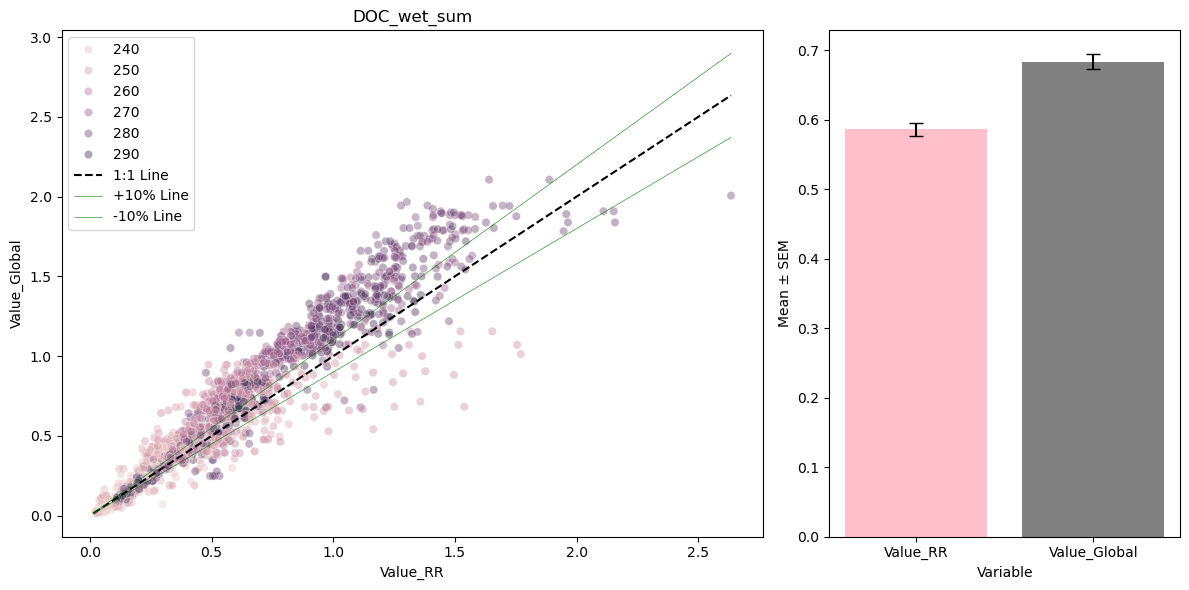

PREC_tot_mm
NRMSE = 0.26
R = 0.92


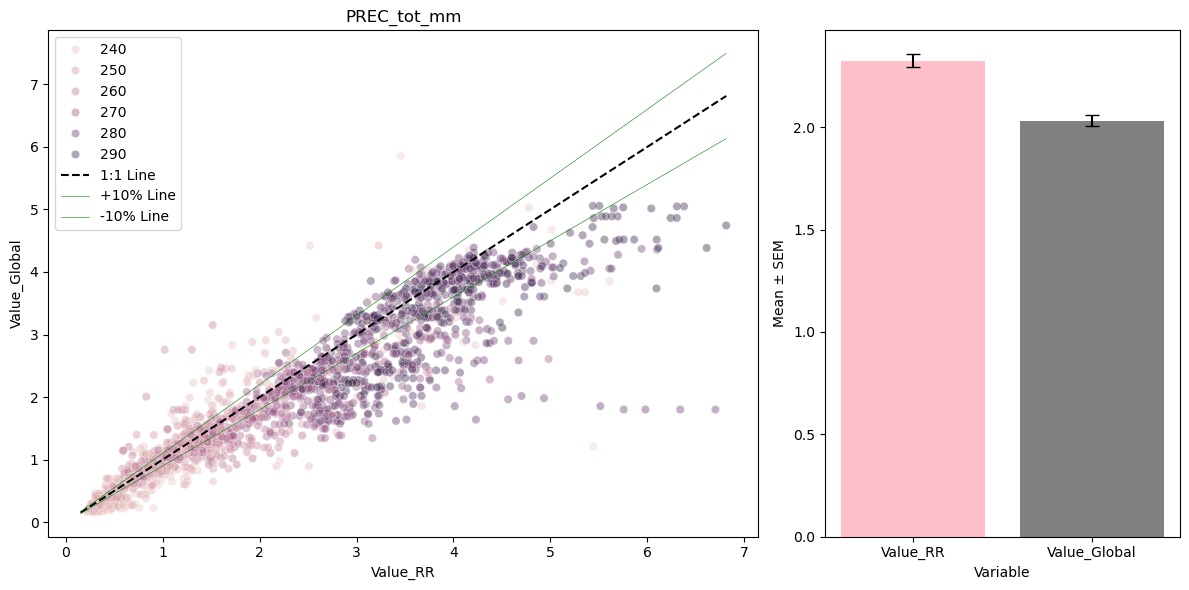

SO4_wet_sum
NRMSE = 0.2
R = 0.96


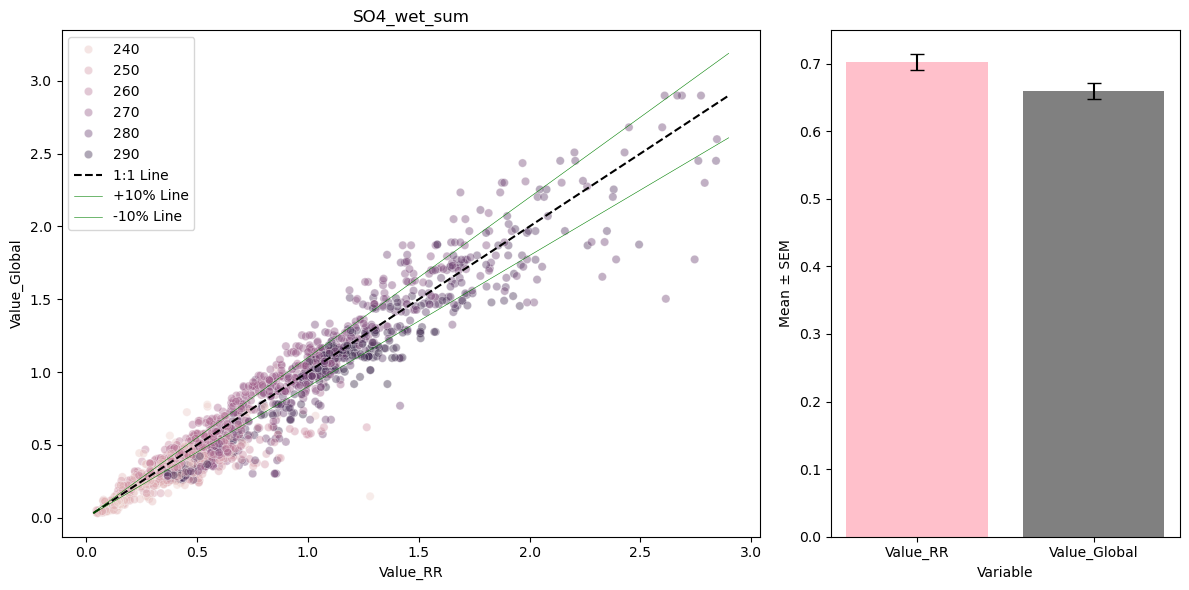

WD_NH4_corr
NRMSE = 0.3
R = 0.96


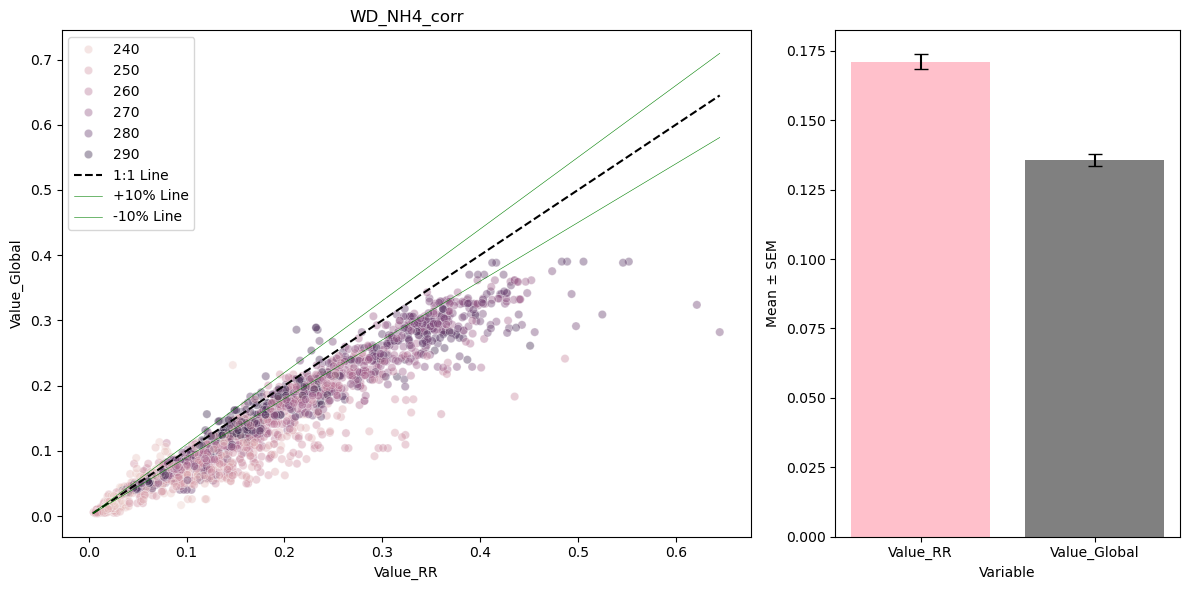

WD_NH3_corr
NRMSE = 0.23
R = 0.96


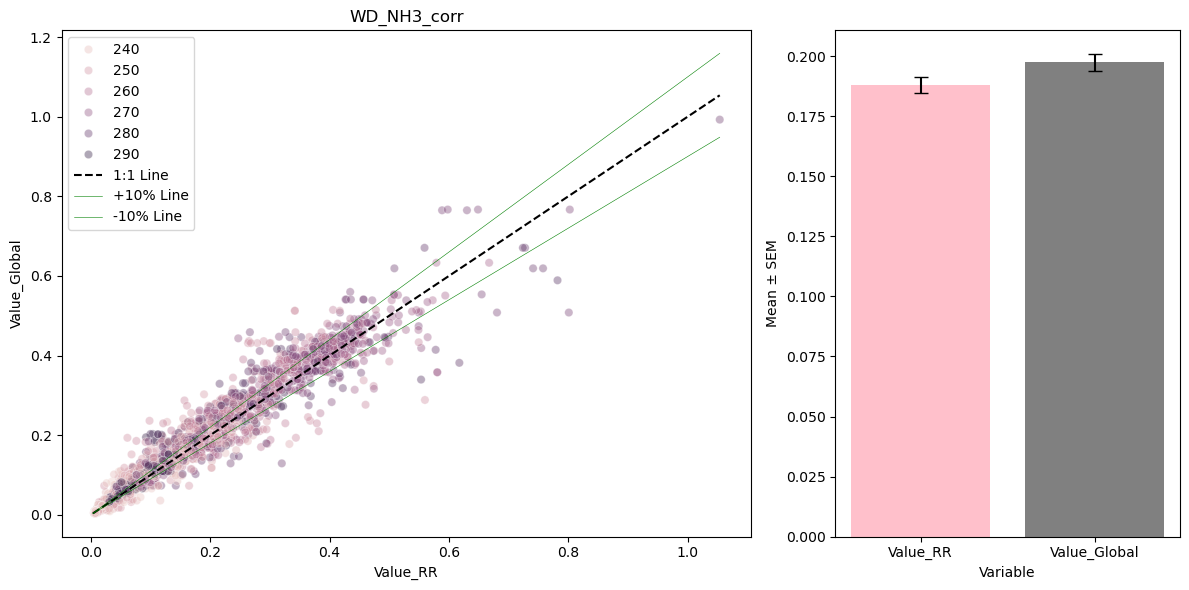

NO3_wet
NRMSE = 0.21
R = 0.97


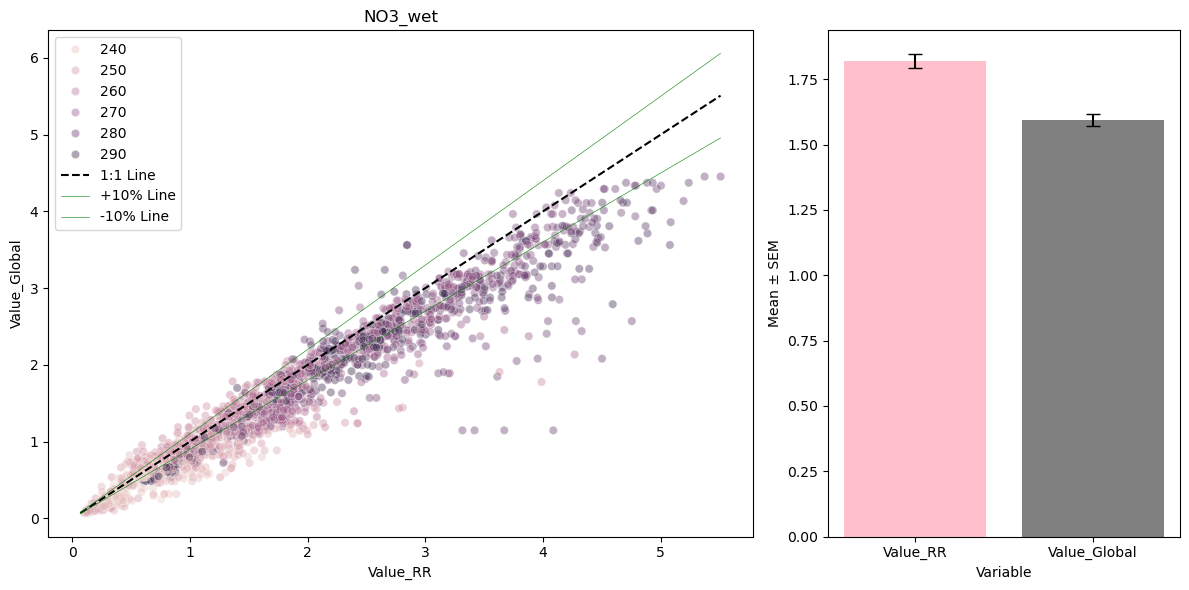

In [15]:
#Now can start to visualize and calculate statistics between these two dfs:

for i in df_mean_glob_RR.variable.unique():
    print(i)
    dat = df_mean_glob_RR.loc[df_mean_glob_RR.variable == i,]
    #Perc_Diff = (((dat['Value_RR'] - dat['Value_Global']).abs()) / ((dat['Value_RR'] + dat['Value_Global']) / 2) * 100).mean()
    #print(f"% Difference = {Perc_Diff:.2g}")
    dat_nrmse = nrmse(dat['Value_RR'], dat['Value_Global'])
    print(f"NRMSE = {dat_nrmse:.2g}")
    #dat_cohens = calculate_cohens_d(dat['Value_RR'], dat['Value_Global'])
    #print(f"Cohen's d = {dat_cohens:.2g}")
    #dat_cohens_interp = interpret_cohens_d(dat_cohens)
    #print(f"Cohen's d interp = {dat_cohens_interp}")
    t_stat, p_value = stats.ttest_ind(dat['Value_RR'], dat['Value_Global'])
    #print(f"t-stats = {t_stat:.2g}")
    #print(f"p_value (t) = {p_value:.2g}")
    r, p_value_r = pearsonr(dat['Value_RR'], dat['Value_Global'])
    print(f"R = {r:.2g}")
    #print(f"p_value (R) = {p_value_r:.2g}")
    
    # Prepare figure with 2 subplots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # Panel 1: Scatter plot
    sns.scatterplot(data=dat, x='Value_RR', y='Value_Global', hue='lon_glob', ax=axes[0], alpha = 0.4)
    min_val = min(min(dat['Value_RR']), min(dat['Value_Global']))
    max_val = max(max(dat['Value_RR']), max(dat['Value_Global']))
    axes[0].plot([min_val, max_val], [min_val, max_val], 'k--', label='1:1 Line')  # 1:1 line
    axes[0].plot([min_val, max_val], [1.1 * min_val, 1.1 * max_val], 'g', label='+10% Line', linewidth=0.4)  # +10%
    axes[0].plot([min_val, max_val], [0.9 * min_val, 0.9 * max_val], 'g', label='-10% Line', linewidth=0.4)  # -10%
    axes[0].set_title(i)
    axes[0].set_xlabel('Value_RR')
    axes[0].set_ylabel('Value_Global')
    axes[0].legend()

    # Panel 2: Mean values plot with error bars
    means = [dat['Value_RR'].mean(), dat['Value_Global'].mean()]
    errors = [dat['Value_RR'].std() / np.sqrt(len(dat['Value_RR'])),  # SEM for Value_RR
              dat['Value_Global'].std() / np.sqrt(len(dat['Value_Global']))]  # SEM for Value_Global
    
    axes[1].bar(['Value_RR', 'Value_Global'], means, color=['pink', 'grey'], yerr=errors, capsize=5)
    axes[1].set_ylabel('Mean ± SEM')
    axes[1].set_xlabel('Variable')
    
    # Show the full figure
    plt.tight_layout()
    plt.savefig(f'/glade/u/home/demurray/External File Uploads/Figures/RR Global random comparison {i}.jpg', format='jpg', dpi=300)  # Adjust quality as needed (0 to 100)
    plt.show()